In [17]:
import pandas as pd
import os
from pathlib import Path

#Setting the path
REPO_NAME = "earthwatch-cnn"
BASE_DIR = next(
    p for p in Path.cwd().parents
    if p.name == REPO_NAME)
DATA_DIR = BASE_DIR / "data"

#Loading the data
data = pd.read_excel(DATA_DIR / "merged_metadata.xlsx")

In [2]:
# Check total count and class balance
print(f"Total images found: {len(data)}")
print(data['feedback_score'].value_counts())

Total images found: 9004
feedback_score
3    3873
1    3259
2    1872
Name: count, dtype: int64


In [18]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

IMG_SIZE = (224, 224)

def valid_image(path):
    img = cv2.imread(path)
    return img is not None

data = data[data['image_path'].apply(valid_image)]

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0
    return img

In [19]:
# Check
print(data.columns)

Index(['downloaded_utc', 'layer_title', 'layer_id', 'feature_object_id',
       'feature_global_id', 'geometry_x', 'geometry_y', 'attachment_id',
       'attachment_global_id', 'attachment_name',
       ...
       'feedback_score', 'County', 'RBD_NAME', 'MNCAT_NAME',
       'Nitrate (mg/L) MID', 'Phosphate (mg/L) MID', 'Photo URL', 'x', 'y',
       'image_path'],
      dtype='object', length=156)


In [20]:
# Load all images into an array
images = np.array([load_image(path) for path in data['image_path']])

# Convert labels to binary classification (0=poor, 1=not poor)
orig_labels = data['feedback_score'].values
labels = (orig_labels >= 2).astype(int)

label_key  = {0: "poor", 1: "not poor"}


In [19]:
# Counts of each type in data
unique, counts = np.unique(labels, return_counts=True)
counts_dict = dict(zip(unique, counts))

print("Data Distribution")
for idx, count in counts_dict.items():
    print(f"{label_key[idx].capitalize()}: {count} images")

Data Distribution
Poor: 3258 images
Not poor: 5738 images


In [20]:
# Split into train/test data
X_train, X_test, y_train, y_test = train_test_split(images, labels, stratify=labels, test_size=0.2, random_state=42)

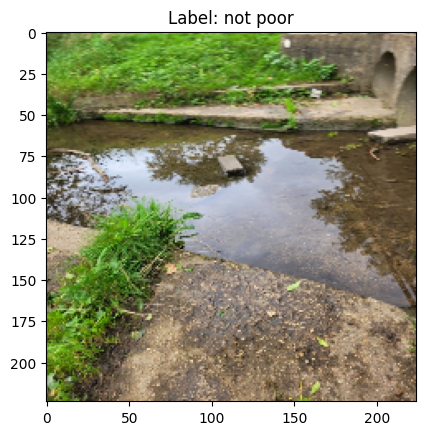

In [25]:
# Check
import matplotlib.pyplot as plt
plt.imshow(X_train[0])
plt.title(f"Label: {label_key[y_train[0]]}")
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Input

# Weight image types (ie. so the CNN doesn't guess the most prominent label each time)
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))

# Prevent overfitting with augmentation (water looks the same flipped, sunny vs. cloudy days)
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    # pixels stay within [0, 1] after brightness changes
    image = tf.clip_by_value(image, 0.0, 1.0) 
    return image, label

# Training Dataset - converts np array to tf dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(len(X_train)).map(augment).batch(64).prefetch(tf.data.AUTOTUNE) #shuffles, augments, batches data for CNN

# Validation Dataset
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(64).prefetch(tf.data.AUTOTUNE)

# CNN
model = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation='relu'), 
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2, 2)),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout to prevent overfitting
    Dense(1, activation='sigmoid') # Binary output
])

# Compile/Train (tweak learning rate and epochs as needed)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(train_ds, epochs=15, validation_data=val_ds, class_weight=class_weights_dict)

# Evaluate
test_loss, test_acc = model.evaluate(val_ds)
print(f"Test Accuracy: {test_acc}")

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.4932 - loss: 0.6952 - val_accuracy: 0.3622 - val_loss: 0.6971
Epoch 2/15


KeyboardInterrupt: 

In [ ]:
#Accuracy and Loss plots

import matplotlib.pyplot as plt

# Accuracy plot
acc = history_dict.get('accuracy', history_dict.get('acc', []))
val_acc = history_dict.get('val_accuracy', history_dict.get('val_acc', []))
plt.figure(figsize=(6,4))
plt.plot(acc, label='train_accuracy')
plt.plot(val_acc, label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')
plt.savefig('cnn_accuracy.png', dpi=150)
plt.show()

# Loss plot
loss = history_dict.get('loss', [])
val_loss = history_dict.get('val_loss', [])
plt.figure(figsize=(6,4))
plt.plot(loss, label='train_loss')
plt.plot(val_loss, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')
plt.savefig('cnn_loss.png', dpi=150)
plt.show()

In [ ]:
# Predicted distribution
preds = model.predict(val_ds)
pred_labels = preds.argmax(axis=1)           
import numpy as np
print(np.unique(pred_labels, return_counts=True))

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, pred_labels))
print(classification_report(y_test, pred_labels))